![image.png](https://i.imgur.com/a3uAqnb.png)
# Lab 2: Speech-to-Text (STT / ASR)

This notebook explores **automatic speech recognition** — from the classical Bayes formulation and WER metric to acoustic features and Whisper inference.

You will implement evaluation code, visualize MFCCs, and run a foundation ASR model on real audio.

> 💡 ASR quality is measured at the **word** level (WER), but models operate on **frames** of acoustic features. Bridge that gap in your answers.

__Let's set up the environment.__ Install dependencies below, then run the import cell.



# 📦 Installing Required Python Libraries

This cell installs packages needed for this lab.

- **PyTorch / Torchaudio** — Audio datasets (e.g. LibriSpeech) and tensor ops.
- **Transformers** — Whisper and ASR pipelines.
- **Librosa** — MFCC and log-mel feature extraction.
- **Matplotlib / NumPy** — Spectrogram visualization.


In [8]:
!pip install -q torch torchaudio transformers datasets accelerate diffusers librosa soundfile matplotlib numpy scipy


# 📥 Importing Essential Python Libraries

Standard imports for Part B programming exercises and GPU checks.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
print(f"PyTorch {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


PyTorch 2.11.0+cpu
CUDA available: False


---

## 💻 Part A — Introduction & Preliminaries
__Let's implement the core ideas in PyTorch.__



### 🛠️ A1. Word Error Rate (WER) implementation

In [3]:
def word_error_rate(reference: str, hypothesis: str) -> float:
    """Compute WER using Levenshtein distance at word level."""
    ref = reference.lower().split()
    hyp = hypothesis.lower().split()
    if not ref:
        return 0.0 if not hyp else 1.0
    n, m = len(ref), len(hyp)
    dp = [[0] * (m + 1) for _ in range(n + 1)]
    for i in range(n + 1):
        dp[i][0] = i
    for j in range(m + 1):
        dp[0][j] = j
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = 0 if ref[i - 1] == hyp[j - 1] else 1
            dp[i][j] = min(dp[i - 1][j] + 1, dp[i][j - 1] + 1, dp[i - 1][j - 1] + cost)
    return dp[n][m] / n

assert abs(word_error_rate("the cat sat", "the cat sat") - 0.0) < 1e-6
assert abs(word_error_rate("the cat sat", "the dog sat") - 1 / 3) < 1e-6
print("WER tests passed.")

WER tests passed.


### 🛠️ A2. Acoustic features

Extract **MFCC** or **log-mel** features and visualize an utterance.

MFCC shape: (13, 32)


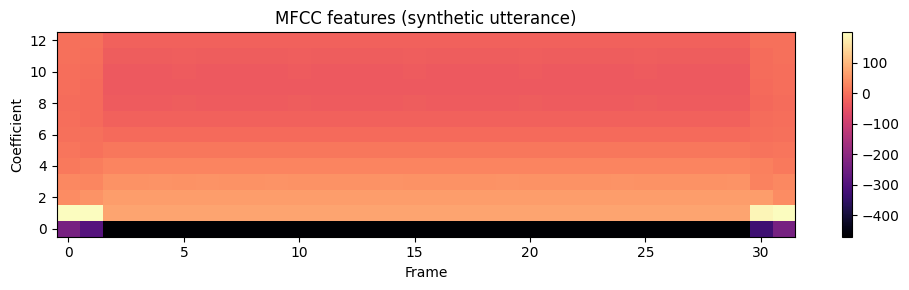

In [24]:
import librosa

sr = 16000
t = np.linspace(0, 1.0, sr)
waveform = 0.5 * np.sin(2 * np.pi * 200 * t) + 0.2 * np.sin(2 * np.pi * 400 * t)
waveform = waveform.astype(np.float32)

mfccs = librosa.feature.mfcc(y=waveform, sr=sr, n_mfcc=13)
print(f"MFCC shape: {mfccs.shape}")
plt.figure(figsize=(10, 3))
plt.imshow(mfccs, aspect="auto", origin="lower", cmap="magma")
plt.title("MFCC features (synthetic utterance)")
plt.xlabel("Frame")
plt.ylabel("Coefficient")
plt.colorbar()
plt.tight_layout()
plt.show()

#### 👀 Commentary (B2)

**MFCCs** emphasize **short-term spectral envelope** shaped by the vocal tract, capturing **phonetic/articulatory** information (formant-like cues). They de-emphasize fine pitch harmonics (via mel + DCT compression), making them robust for **phone discrimination**.

### 🛠️ A3. Whisper transcription

Run OpenAI **Whisper** (via `transformers`) on a short clip.

In [10]:
import matplotlib.pyplot as plt
import numpy as np

In [5]:

sr = 16000
duration = 2.0
t = np.linspace(0, duration, int(sr * duration))
waveform = (0.3 * np.sin(2 * np.pi * 220 * t)).astype(np.float32)
reference = "beep"

try:
    from transformers import pipeline
    asr = pipeline("automatic-speech-recognition", model="openai/whisper-tiny")
    result = asr({"array": waveform, "sampling_rate": sr})
    hypothesis = result["text"].strip()
    print("Transcript:", hypothesis)
    print(f"WER vs reference '{reference}':", word_error_rate(reference, hypothesis))
except Exception as exc:
    print(f"Whisper demo skipped ({exc}). WER implementation verified above.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.98k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/151M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/3.75k [00:00<?, ?B/s]

...

added_tokens.json:   0%|          | 0.00/34.6k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.19k [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

[transformers] Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
[transformers] Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see re

Transcript: . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
WER vs reference 'beep': 444.0



# Part B: Non-English ASR

In this part of this assignment, you will leverage  large, pretrained speech models of choice to do ASR non-English languages. For this part, are free to use any model available on HuggingFace.


We will be looking at these four languages in this section:


*   Lingala (`ln_cd`)
*   Korean(`ko_kr`)
*   isiXhosa (`xh_za`)
*   isiZulu (`zu_za`)
*   Irish (`ga_ie`)



##### Part B Imports

In [12]:
!pip install -q evaluate
!pip install -q datasets
!pip install -q jiwer
!pip install -U -q transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 98.5 MB/s eta 0:00:00


In [13]:
from datasets import load_dataset
from evaluate import evaluator
# Uncomment below to remake the Telugu dataset
# tel_test = load_dataset("google/fleurs", "te_in", split="test")

## Inference example

Below is an example of how to get the WER of a loaded dataset:

This code runs inference with a single model for the test set of a single chosen language. You can use this as a starting point to run inference and evaluations on different models and languages.

You can change the model you evaluate by changing the `model_name` variable.

As an example, we will continue to use the Telugu test set from FLEURS.

In [14]:
model_name = "AntonyG/fine-tune-wav2vec2-large-xls-r-1b-sw"

# Load data and evaluator
task_evaluator = evaluator("automatic-speech-recognition")
tel_test = load_dataset("google/fleurs", "te_in", split="test[:100]")

# temp fix - from https://github.com/huggingface/evaluate/issues/437
task_evaluator.PIPELINE_KWARGS.pop('truncation', None)
assert 'truncation' not in task_evaluator.PIPELINE_KWARGS

# Compute WER
results = task_evaluator.compute(
    model_or_pipeline=model_name,
    data=tel_test,
    input_column="audio",
    label_column="transcription",
    metric="wer",
)
results

README.md:   0%|          | 0.00/386k [00:00<?, ?B/s]

parquet-data/te_in/train-00000-of-00001.(…):   0%|          | 0.00/1.81G [00:00<?, ?B/s]

parquet-data/te_in/validation-00000-of-0(…):   0%|          | 0.00/205M [00:00<?, ?B/s]

parquet-data/te_in/test-00000-of-00001.p(…):   0%|          | 0.00/332M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2302 [00:00<?, ? examples/s]

...

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/320 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/96.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/214 [00:00<?, ?B/s]

{'wer': 1.1529828706438274,
 'total_time_in_seconds': 15.955108117000236,
 'samples_per_second': 6.267585231431279,
 'latency_in_seconds': 0.15955108117000236}

## B.1 Filter dataset by utterance length

### B.1.1 Add input length to dataset

 `add_input_length` to adds the length of the utterance to the dataset with the attribute `input_length`.


In [15]:
def add_input_length(batch):
    audio = batch["audio"]

    batch["input_length"] = len(audio["array"]) / audio["sampling_rate"]
    return batch

### B.1.2 Task: Remove utterances longer than 30 seconds

Let's filter out utterances longer than 30 seconds out of the dataset.Write a function called `is_audio_length_in_range` to filters out utterances over 30 seconds using the `input_length` that is now in your dataset.

In [20]:
def is_audio_length_in_range(batch):
    return batch["input_length"] <= 30

In [21]:
tel_test = tel_test.map(add_input_length)
tel_test = tel_test.filter(is_audio_length_in_range, input_columns=["input_length"])


Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Filter:   0%|          | 0/100 [00:00<?, ? examples/s]

TypeError: 'float' object is not subscriptable

### B.1.3 Task: Make length-based subsets of the dataset (3 points)

Let's make subsets of the dataset based on utterance length. For these datasets we have three utterance lengths:

*   Short (0-10 seconds)
*   Medium (10 - 16 seconds)
*   Long (16 - 30 seconds)


Write a funntion to turn a dataset into a `small`, `medium`, and `longer` dataset based on the utterance lengths above.

In [22]:
def make_utterance_datasets(dataset):
    small = dataset.filter(lambda batch: batch["input_length"] <= 10)
    medium = dataset.filter(lambda batch: batch["input_length"] > 10 and batch["input_length"] <= 16)
    longer = dataset.filter(lambda batch: batch["input_length"] > 16 and batch["input_length"] <= 30)
    return small, medium, longer

In [23]:
small, medium, longer = make_utterance_datasets(tel_test)

Filter:   0%|          | 0/100 [00:00<?, ? examples/s]

Filter:   0%|          | 0/100 [00:00<?, ? examples/s]

Filter:   0%|          | 0/100 [00:00<?, ? examples/s]

### B.1.4 Task: Make length-based datasets for our 5 languages (5 points)

Now do this for each of the 5 languages we will be working with:


*   Lingala (`ln_cd`)
*   Korean(`ko_kr`)
*   isiXhosa (`xh_za`)
*   isiZulu (`zu_za`)
*   Irish (`ga_ie`)


Return a `dataset_length_dict` with keys being the lowercase language names and values being `[num_short, num_med, num_long]` utterances per language.

In [ ]:
#############################
#### YOUR CODE GOES HERE ####

#############################

### B.1.5 Sanity check your function

In [18]:
def check(d_dict):
  return d_dict == {'lingala': [27, 153, 260], 'korean': [87, 231, 64], 'isiXhosa': [278, 538, 218], 'irish': [126, 418, 285], 'isiZulu': [97, 383, 342]}


In [ ]:
check(dataset_length_dict)

## B.2 Task: Compute aggregate word error rate across several languages and utterance lengths



Compute the word error rate of the test set for each of these languages across different utterance lengths.

Utterance lengths:


*   Short (0-10 seconds)
*   Medium (10 - 16 seconds)
*   Long (16 - 30 seconds)

Languages:

*   Lingala (`ln_cd`)
*   Korean(`ko_kr`)
*   isiXhosa (`xh_za`)
*   isiZulu (`zu_za`)
*   Irish (`ga_ie`)


Start with MMS 1B `facebook/mms-1b-all` and see if you can find a better model that reduces the WER on medium length utterances across all languages.


We would like a table of WER by utterance length per language for at least two publicly available models.

### Step-by-step guide to 2.2
For those who find it helpful, here is a **step-by-step guide** to creating a basic code block that runs:

**1 Environment preparation**
Start each session by making sure you have a GPU runtime and modern libraries.

* Upgrade the core stack via !pip install -U "transformers>=4.40" sentencepiece soundfile

* Restart the runtime so the new version of transformers is picked up.

* Authenticate once per runtime if you plan on touching Common Voice or gated MMS files:
  from huggingface_hub import login → paste your write token.

**2 Pull the FLEURS test split and attach duration**
For each target language code (e.g. ln_cd for Lingala)

1. Load the "test" split.

2. Immediately cast the audio column to a 16 kHz sampling rate – MMS assumes that rate.

3. Compute a dur field in seconds (len(array) / sampling_rate) via .map.

That dataset object will be reused for every model and length bucket.

*Gotcha*: forgetting the Audio(sampling_rate=16_000) cast will silently resample at runtime and make you wait forever.

**3 Duration buckets**
Use duration buckets you have created above.

**4 ASR pipelines**
**4 ASR pipeline (facebook/mms-1b-all)**
To create a working pipeline:

Load facebook/mms-1b-all with target_lang=<ISO-639-3> via AutoProcessor + AutoModelForCTC; then build a pipeline with the returned tokenizer, feature extractor and model.

Debug checklist

* If every WER is ~1.0 you probably forgot to pass target_lang when loading facebook/mms-1b-all.

**5 Batch inference and WER**
Inside the double-for-loop language × duration-bin:

1. Call the pipeline on bucket["audio"] with a modest batch size (8 fits into a 12 GB V100).

2. Lower-case both hypotheses and references before computing WER via evaluate.load("wer").

3. Append a record {language, len_bin, model, WER} to a running Python list.

Print progress as you go so you can see which combination is slow or failing.

**6 Pivot and inspect**
After the loops finish, convert the list into a pandas.DataFrame and call


df.pivot_table(values="WER",
               index=["language", "len_bin"]).sort_index()

That single line produces exactly the table the graders expect: one row per language-bin, one column per model, lower = better.

**7 Typical outcomes & interpretation**
* MMS-1B-all plus the correct adapter yields WER ≈ 0.20 – 0.40 on these languages.

* The assignment asks you to beat MMS on the medium bucket → obvious next step is to swap in language-specific MMS checkpoints or a community fine-tune.

Use those observations, not my numbers, when you write your reflection.

**8 Trouble-shooting cheatsheet**

* Endless download loops → nuke the faulty cache folder under ~/.cache/huggingface/hub and re-run.

* Runtime slows to a crawl → confirm the “Device set to use cuda:0” banner; Colab occasionally drops back to CPU.

* Tokenizer error on MMS after a restart → recreate the temp vocab; the directory is ephemeral.

In [ ]:
#############################
#### YOUR CODE GOES HERE ####
#############################





#############################